In [ ]:
# Standard library imports
import time
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn — preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer

# Scikit-learn — models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# GPU-accelerated SVC when available (DGX Spark / RAPIDS), else CPU sklearn
try:
    from cuml.svm import SVC  # GPU
    _SVC_BACKEND = "cuml"
except ImportError:
    from sklearn.svm import SVC  # CPU fallback
    _SVC_BACKEND = "sklearn"
from sklearn.svm import LinearSVC

print(f"SVC backend: {_SVC_BACKEND}")

#pipeline
from sklearn.pipeline import Pipeline

# Scikit-learn — metrics
from sklearn.metrics import (
    accuracy_score, classification_report, 
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv('../data/bank-additional-full.csv', sep=';')

In [3]:
#drop duration
df = df.drop(columns=['duration'])

#encode as binary
df['y'] = (df['y'] == 'yes').astype(int)

#change pdays to binary because 999 implies no prior contact, changing it to 0 might skew the model
df['p_contacted'] = (df['pdays'] != 999).astype(int)
df = df.drop(columns=['pdays'])  



In [4]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [5]:
X = df.drop('y', axis=1, inplace=False)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

### Dummy Classifier
Determine Baseline

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

preprocessor = make_column_transformer(
    (StandardScaler(), num_cols),
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
)

dummy_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent', random_state=42)),
])

dummy_pipe.fit(X_train, y_train)
y_pred_dummy = dummy_pipe.predict(X_test)
y_prob_dummy = dummy_pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_dummy):.4f}")
print()
print(classification_report(y_test, y_pred_dummy, target_names=['no', 'yes']))

### Logistic Regression Pipeline
Build a full preprocessing + model pipeline using `StandardScaler` for numeric features and `OneHotEncoder` for categorical features.

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

preprocessor = make_column_transformer(
    (StandardScaler(), num_cols),
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
)

lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipe.fit(X_train, y_train)
y_pred = lr_pipe.predict(X_test)
y_prob = lr_pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

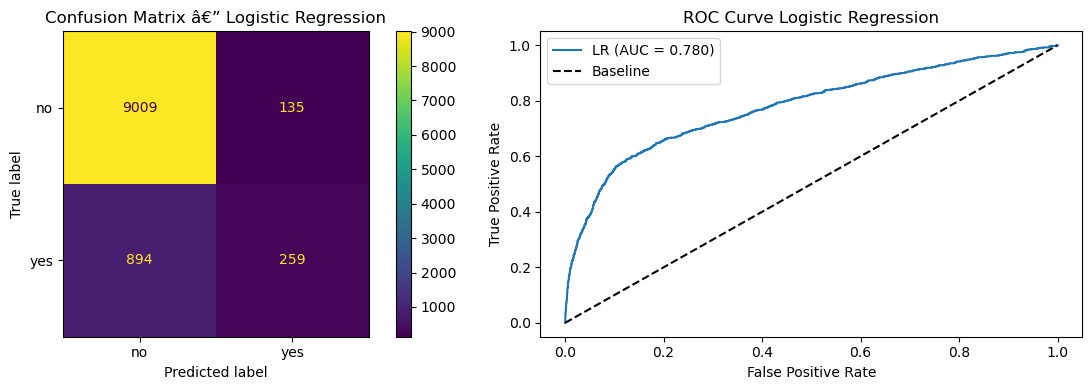

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['no', 'yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix â€” Logistic Regression')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'LR (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.show()

### Logistic Regression Stratified K-Fold Cross-Validation
Evaluate the same pipeline with 5-fold stratified cross-validation to get a more robust estimate of generalisation performance.

In [24]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(lr_pipe, X, y, cv=skf, scoring='accuracy')
cv_roc_auc  = cross_val_score(lr_pipe, X, y, cv=skf, scoring='roc_auc')

print("Logistic Regression 5-Fold Stratified CV")
print(f"  Accuracy : {cv_accuracy.mean():.4f}  (+/- {cv_accuracy.std():.4f})")
print(f"  ROC-AUC  : {cv_roc_auc.mean():.4f}  (+/- {cv_roc_auc.std():.4f})")

cv_results = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_accuracy,
    'ROC-AUC': cv_roc_auc,
})
print()
print(cv_results.to_string(index=False))

Logistic Regression 5-Fold Stratified CV
  Accuracy : 0.9000  (+/- 0.0029)
  ROC-AUC  : 0.7916  (+/- 0.0068)

 Fold  Accuracy  ROC-AUC
    1  0.896091 0.788647
    2  0.900825 0.785442
    3  0.904953 0.804530
    4  0.899478 0.787544
    5  0.898871 0.791794


### K-Nearest Neighbors Pipeline
Same preprocessing pipeline with `KNeighborsClassifier` as the estimator.

In [10]:
knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier()),
])

knn_pipe.fit(X_train, y_train)
y_pred_knn = knn_pipe.predict(X_test)
y_prob_knn = knn_pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_knn):.4f}")
print()
print(classification_report(y_test, y_pred_knn, target_names=['no', 'yes']))

Accuracy : 0.8895
ROC-AUC  : 0.7213

              precision    recall  f1-score   support

          no       0.92      0.96      0.94      9144
         yes       0.51      0.30      0.37      1153

    accuracy                           0.89     10297
   macro avg       0.71      0.63      0.66     10297
weighted avg       0.87      0.89      0.88     10297



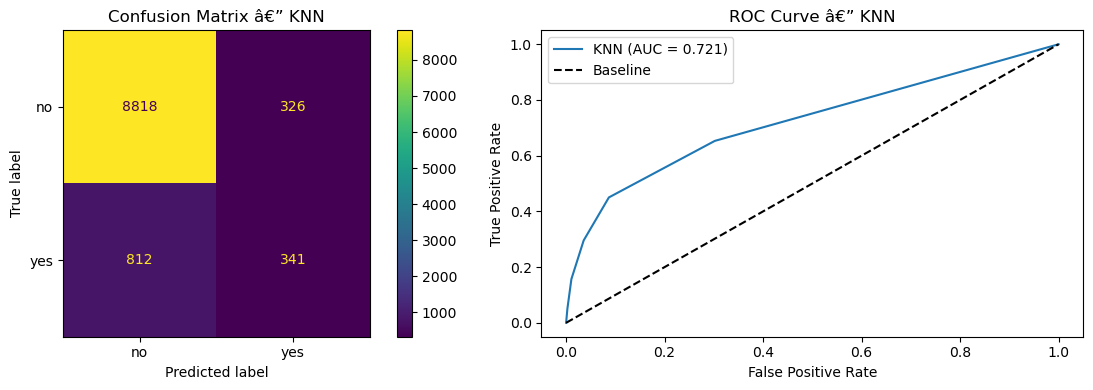

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, display_labels=['no', 'yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix KNN')

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)
axes[1].plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve KNN')
axes[1].legend()

plt.tight_layout()
plt.show()

### KNN â€” Stratified K-Fold Cross-Validation

In [ ]:
cv_accuracy_knn = cross_val_score(knn_pipe, X, y, cv=skf, scoring='accuracy')
cv_roc_auc_knn  = cross_val_score(knn_pipe, X, y, cv=skf, scoring='roc_auc')

print("KNN 5-Fold Stratified CV")
print(f"  Accuracy : {cv_accuracy_knn.mean():.4f}  (+/- {cv_accuracy_knn.std():.4f})")
print(f"  ROC-AUC  : {cv_roc_auc_knn.mean():.4f}  (+/- {cv_roc_auc_knn.std():.4f})")

cv_results_knn = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_accuracy_knn,
    'ROC-AUC': cv_roc_auc_knn,
})
print()
print(cv_results_knn.to_string(index=False))

KNN â€” 5-Fold Stratified CV
  Accuracy : 0.8910  (+/- 0.0019)
  ROC-AUC  : 0.7296  (+/- 0.0084)

 Fold  Accuracy  ROC-AUC
    1  0.888565 0.715730
    2  0.889172 0.724678
    3  0.892085 0.738747
    4  0.893651 0.732987
    5  0.891708 0.735924


### Decision Tree Pipeline

In [13]:
dt_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42)),
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)
y_prob_dt = dt_pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=['no', 'yes']))

Accuracy : 0.8415
ROC-AUC  : 0.6211

              precision    recall  f1-score   support

          no       0.91      0.91      0.91      9144
         yes       0.31      0.33      0.32      1153

    accuracy                           0.84     10297
   macro avg       0.61      0.62      0.61     10297
weighted avg       0.85      0.84      0.84     10297



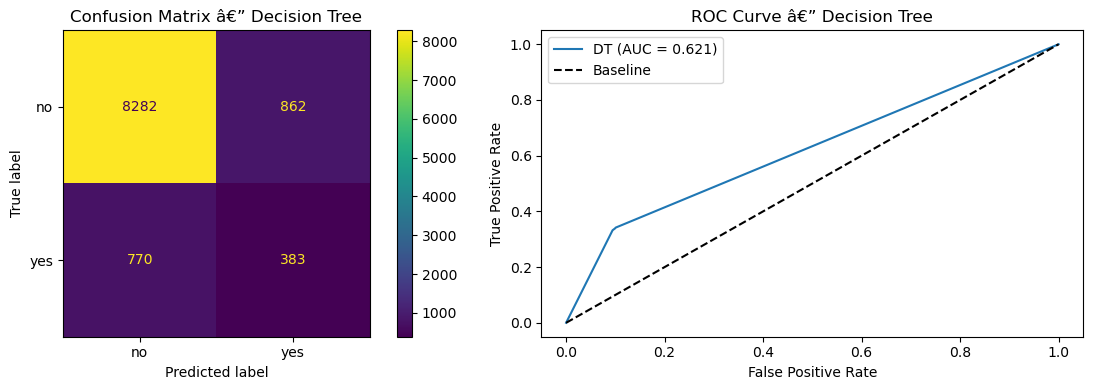

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=['no', 'yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix â€” Decision Tree')

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
axes[1].plot(fpr_dt, tpr_dt, label=f'DT (AUC = {auc_dt:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Decision Tree')
axes[1].legend()

plt.tight_layout()
plt.show()

### Decision Tree â€” Stratified K-Fold Cross-Validation

In [ ]:
cv_accuracy_dt = cross_val_score(dt_pipe, X, y, cv=skf, scoring='accuracy')
cv_roc_auc_dt  = cross_val_score(dt_pipe, X, y, cv=skf, scoring='roc_auc')

print("Decision Tree 5-Fold Stratified CV")
print(f"  Accuracy : {cv_accuracy_dt.mean():.4f}  (+/- {cv_accuracy_dt.std():.4f})")
print(f"  ROC-AUC  : {cv_roc_auc_dt.mean():.4f}  (+/- {cv_roc_auc_dt.std():.4f})")

cv_results_dt = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_accuracy_dt,
    'ROC-AUC': cv_roc_auc_dt,
})
print()
print(cv_results_dt.to_string(index=False))

Decision Tree â€” 5-Fold Stratified CV
  Accuracy : 0.8401  (+/- 0.0019)
  ROC-AUC  : 0.6231  (+/- 0.0053)

 Fold  Accuracy  ROC-AUC
    1  0.838553 0.618594
    2  0.838796 0.627900
    3  0.843044 0.629054
    4  0.841569 0.624638
    5  0.838291 0.615460


### Support Vector Machine Pipeline

In [ ]:
svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(C=1.0, kernel='rbf', random_state=42)),  # no max_iter cap — runs on cuML GPU when available
])

svm_pipe.fit(X_train, y_train)
y_pred_svm = svm_pipe.predict(X_test)
y_score_svm = svm_pipe.decision_function(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_score_svm):.4f}")
print()
print(classification_report(y_test, y_pred_svm, target_names=['no', 'yes']))

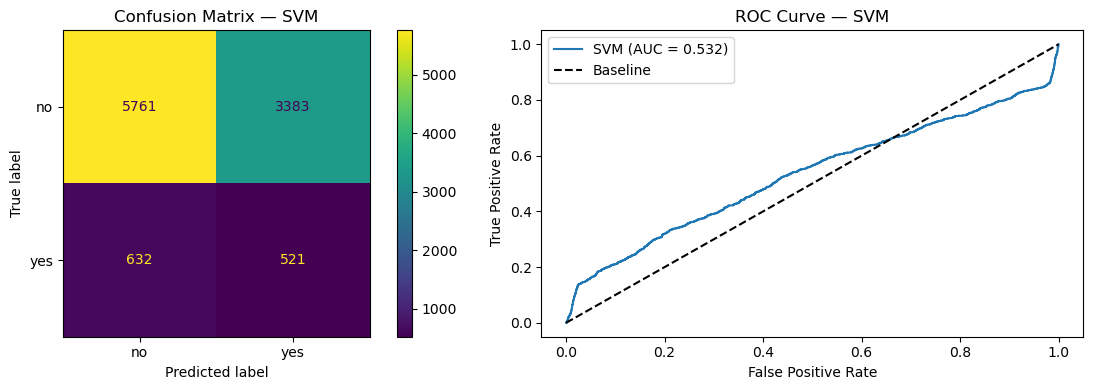

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, display_labels=['no', 'yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix — SVM')

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)
auc_svm = roc_auc_score(y_test, y_score_svm)
axes[1].plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — SVM')
axes[1].legend()

plt.tight_layout()
plt.show()

### SVM Stratified K-Fold Cross-Validation

In [34]:
cv_accuracy_svm = cross_val_score(svm_pipe, X, y, cv=skf, scoring='accuracy')
cv_roc_auc_svm  = cross_val_score(svm_pipe, X, y, cv=skf, scoring='roc_auc')

print("SVM â€” 5-Fold Stratified CV")
print(f"  Accuracy : {cv_accuracy_svm.mean():.4f}  (+/- {cv_accuracy_svm.std():.4f})")
print(f"  ROC-AUC  : {cv_roc_auc_svm.mean():.4f}  (+/- {cv_roc_auc_svm.std():.4f})")

cv_results_svm = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_accuracy_svm,
    'ROC-AUC': cv_roc_auc_svm,
})
print()
print(cv_results_svm.to_string(index=False))

SVM â€” 5-Fold Stratified CV
  Accuracy : 0.6052  (+/- 0.0166)
  ROC-AUC  : 0.5424  (+/- 0.0123)

 Fold  Accuracy  ROC-AUC
    1  0.574047 0.540143
    2  0.619446 0.562291
    3  0.605244 0.529623
    4  0.608353 0.530342
    5  0.618915 0.549362


### GridSearchCV Hyperparameter Tuning Across All Models
Run `GridSearchCV` with `StratifiedKFold` for each model, log wall-clock time, then compare best scores side by side.

In [ ]:
param_grids = {
    'Logistic Regression': {
        'pipe': lr_pipe,
        'params': {
            'model__C':      [0.01, 0.1, 1, 10],
            'model__solver': ['lbfgs', 'liblinear'],
        },
    },
    'KNN': {
        'pipe': knn_pipe,
        'params': {
            'model__n_neighbors': [3, 5, 11, 21],
            'model__weights':     ['uniform', 'distance'],
            'model__metric':      ['euclidean', 'manhattan'],
        },
    },
    'Decision Tree': {
        'pipe': dt_pipe,
        'params': {
            'model__max_depth':        [3, 5, 10, None],
            'model__min_samples_split': [2, 10, 20],
            'model__criterion':        ['gini', 'entropy'],
        },
    },
    'SVM': {
        'pipe': svm_pipe,
        'params': {
            'model__C':      [0.01, 0.1, 1, 10, 100],
            'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
            'model__gamma':  ['scale', 'auto'],
        },
    },
}

# GPU estimators don't parallelize well under joblib — one worker per GPU
per_model_n_jobs = {'SVM': 1 if _SVC_BACKEND == 'cuml' else -1}

gs_results = []

for name, config in param_grids.items():
    print(f"Tuning {name}...")
    start = time.time()

    gs = GridSearchCV(
        config['pipe'],
        config['params'],
        cv=skf,
        scoring='roc_auc',
        n_jobs=per_model_n_jobs.get(name, -1),
        refit=True,
    )
    gs.fit(X_train, y_train)

    elapsed = time.time() - start

    # Time the best estimator's training on the full training set
    best_est = gs.best_estimator_
    t0 = time.time()
    best_est.fit(X_train, y_train)
    train_time = time.time() - t0

    # Time prediction on the test set
    t0 = time.time()
    y_pred_gs = best_est.predict(X_test)
    predict_time = time.time() - t0

    if hasattr(best_est, 'predict_proba'):
        y_score_gs = best_est.predict_proba(X_test)[:, 1]
    else:
        y_score_gs = best_est.decision_function(X_test)

    gs_results.append({
        'Model':           name,
        'Best Params':     gs.best_params_,
        'CV ROC-AUC':      round(gs.best_score_, 4),
        'Test Accuracy':   round(accuracy_score(y_test, y_pred_gs), 4),
        'Test ROC-AUC':    round(roc_auc_score(y_test, y_score_gs), 4),
        'GridSearch (s)':  round(elapsed, 2),
        'Train Time (s)':  round(train_time, 4),
        'Predict Time (s)': round(predict_time, 4),
        'best_estimator':  best_est,
        'y_pred':          y_pred_gs,
        'y_score':         y_score_gs,
    })

    print(f"  Best params  : {gs.best_params_}")
    print(f"  CV ROC-AUC   : {gs.best_score_:.4f}")
    print(f"  Test Acc     : {accuracy_score(y_test, y_pred_gs):.4f}")
    print(f"  Test ROC-AUC : {roc_auc_score(y_test, y_score_gs):.4f}")
    print(f"  GridSearch   : {elapsed:.2f}s")
    print(f"  Train time   : {train_time:.4f}s")
    print(f"  Predict time : {predict_time:.4f}s")
    print()

In [42]:
exclude_keys = ('Best Params', 'best_estimator', 'y_pred', 'y_score')
summary_df = pd.DataFrame([{k: v for k, v in r.items() if k not in exclude_keys} for r in gs_results])
print(summary_df.to_string(index=False))

              Model  CV ROC-AUC  Test Accuracy  Test ROC-AUC  GridSearch (s)  Train Time (s)  Predict Time (s)
Logistic Regression      0.7949         0.9000        0.7806            5.34          0.1700            0.0172
                KNN      0.7714         0.8972        0.7535           18.22          0.0527            0.9133
      Decision Tree      0.7846         0.9009        0.7721            2.87          0.1091            0.0177
                SVM      0.6406         0.4299        0.6606           65.04          3.7538            0.9530


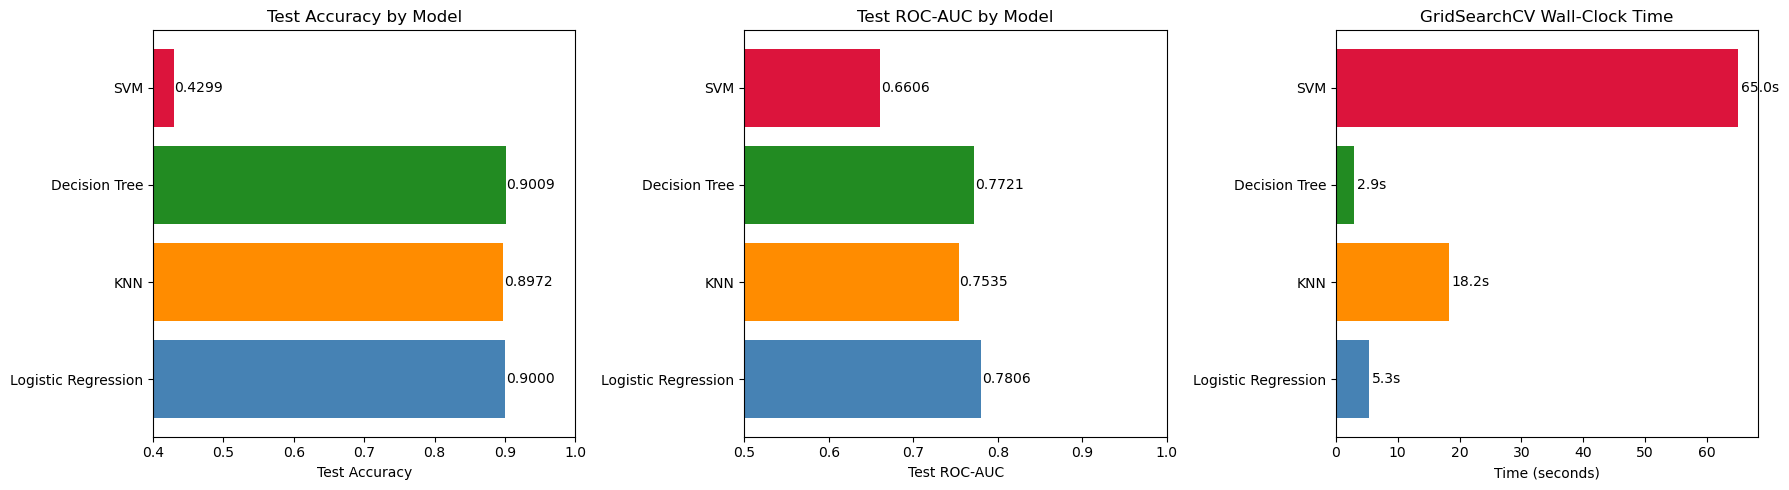

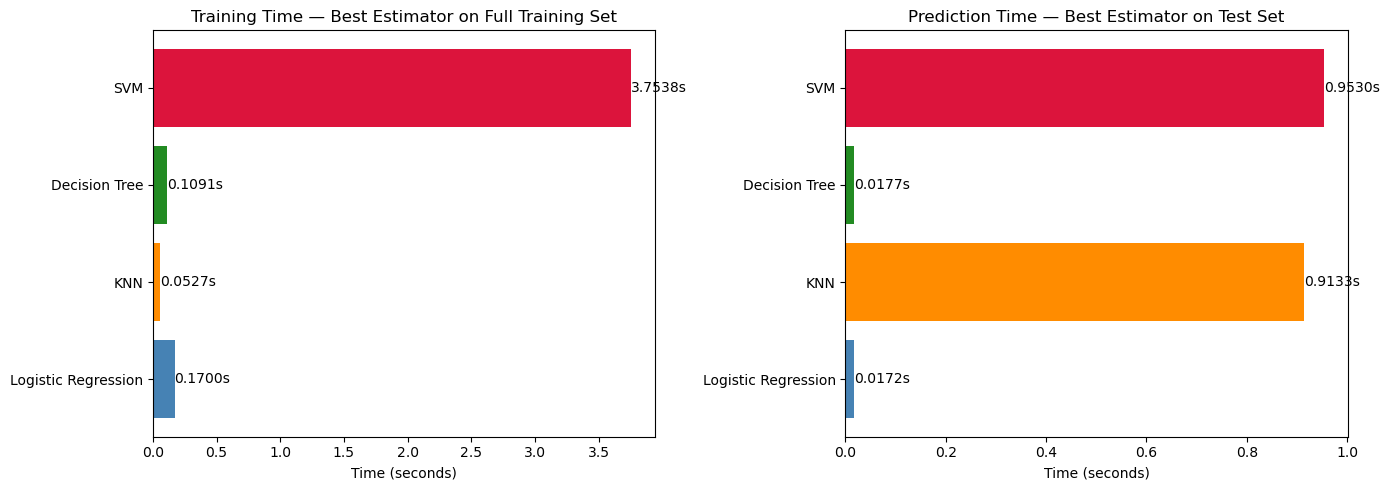

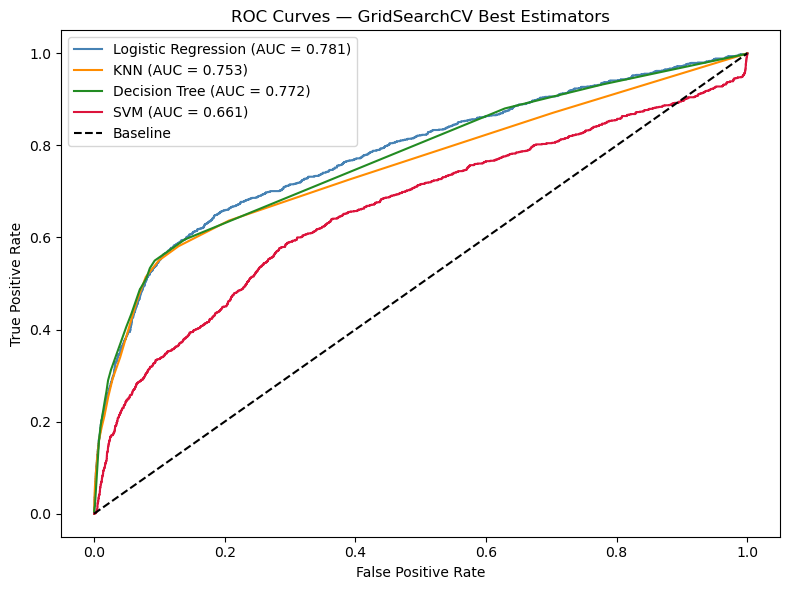

Speed Summary
  Fastest to train   : KNN
  Slowest to train   : SVM
  Fastest to predict : Logistic Regression
  Slowest to predict : SVM

              Model  Train Time (s)  Predict Time (s)
Logistic Regression          0.1700            0.0172
                KNN          0.0527            0.9133
      Decision Tree          0.1091            0.0177
                SVM          3.7538            0.9530


In [43]:
models       = summary_df['Model']
test_acc     = summary_df['Test Accuracy']
test_auc     = summary_df['Test ROC-AUC']
gs_times     = summary_df['GridSearch (s)']
train_times  = summary_df['Train Time (s)']
predict_times = summary_df['Predict Time (s)']
colors       = ['steelblue', 'darkorange', 'forestgreen', 'crimson']

# --- Performance + GridSearch time ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(models, test_acc, color=colors)
axes[0].set_xlim(0.4, 1.0)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Test Accuracy by Model')
for i, v in enumerate(test_acc):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center')

axes[1].barh(models, test_auc, color=colors)
axes[1].set_xlim(0.5, 1.0)
axes[1].set_xlabel('Test ROC-AUC')
axes[1].set_title('Test ROC-AUC by Model')
for i, v in enumerate(test_auc):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center')

axes[2].barh(models, gs_times, color=colors)
axes[2].set_xlabel('Time (seconds)')
axes[2].set_title('GridSearchCV Wall-Clock Time')
for i, v in enumerate(gs_times):
    axes[2].text(v + 0.5, i, f'{v:.1f}s', va='center')

plt.tight_layout()
plt.show()

# --- Training vs Prediction time ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(models, train_times, color=colors)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_title('Training Time — Best Estimator on Full Training Set')
for i, v in enumerate(train_times):
    axes[0].text(v + 0.0005, i, f'{v:.4f}s', va='center')

axes[1].barh(models, predict_times, color=colors)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_title('Prediction Time — Best Estimator on Test Set')
for i, v in enumerate(predict_times):
    axes[1].text(v + 0.0001, i, f'{v:.4f}s', va='center')

plt.tight_layout()
plt.show()

# --- ROC curves overlaid ---
fig, ax = plt.subplots(figsize=(8, 6))
for r, color in zip(gs_results, colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_score'])
    ax.plot(fpr, tpr, label=f"{r['Model']} (AUC = {r['Test ROC-AUC']:.3f})", color=color)
ax.plot([0, 1], [0, 1], 'k--', label='Baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — GridSearchCV Best Estimators')
ax.legend()
plt.tight_layout()
plt.show()

# --- Speed comparison callout ---
fastest_train  = summary_df.loc[summary_df['Train Time (s)'].idxmin(), 'Model']
slowest_train  = summary_df.loc[summary_df['Train Time (s)'].idxmax(), 'Model']
fastest_pred   = summary_df.loc[summary_df['Predict Time (s)'].idxmin(), 'Model']
slowest_pred   = summary_df.loc[summary_df['Predict Time (s)'].idxmax(), 'Model']

print("Speed Summary")
print("=" * 50)
print(f"  Fastest to train   : {fastest_train}")
print(f"  Slowest to train   : {slowest_train}")
print(f"  Fastest to predict : {fastest_pred}")
print(f"  Slowest to predict : {slowest_pred}")
print()
print(summary_df[['Model', 'Train Time (s)', 'Predict Time (s)']].to_string(index=False))

### Logistic Regression Coefficient Plot
Coefficients show the direction and magnitude of each feature's influence on the log-odds of a `yes` subscription outcome. Positive = increases likelihood, negative = decreases it.

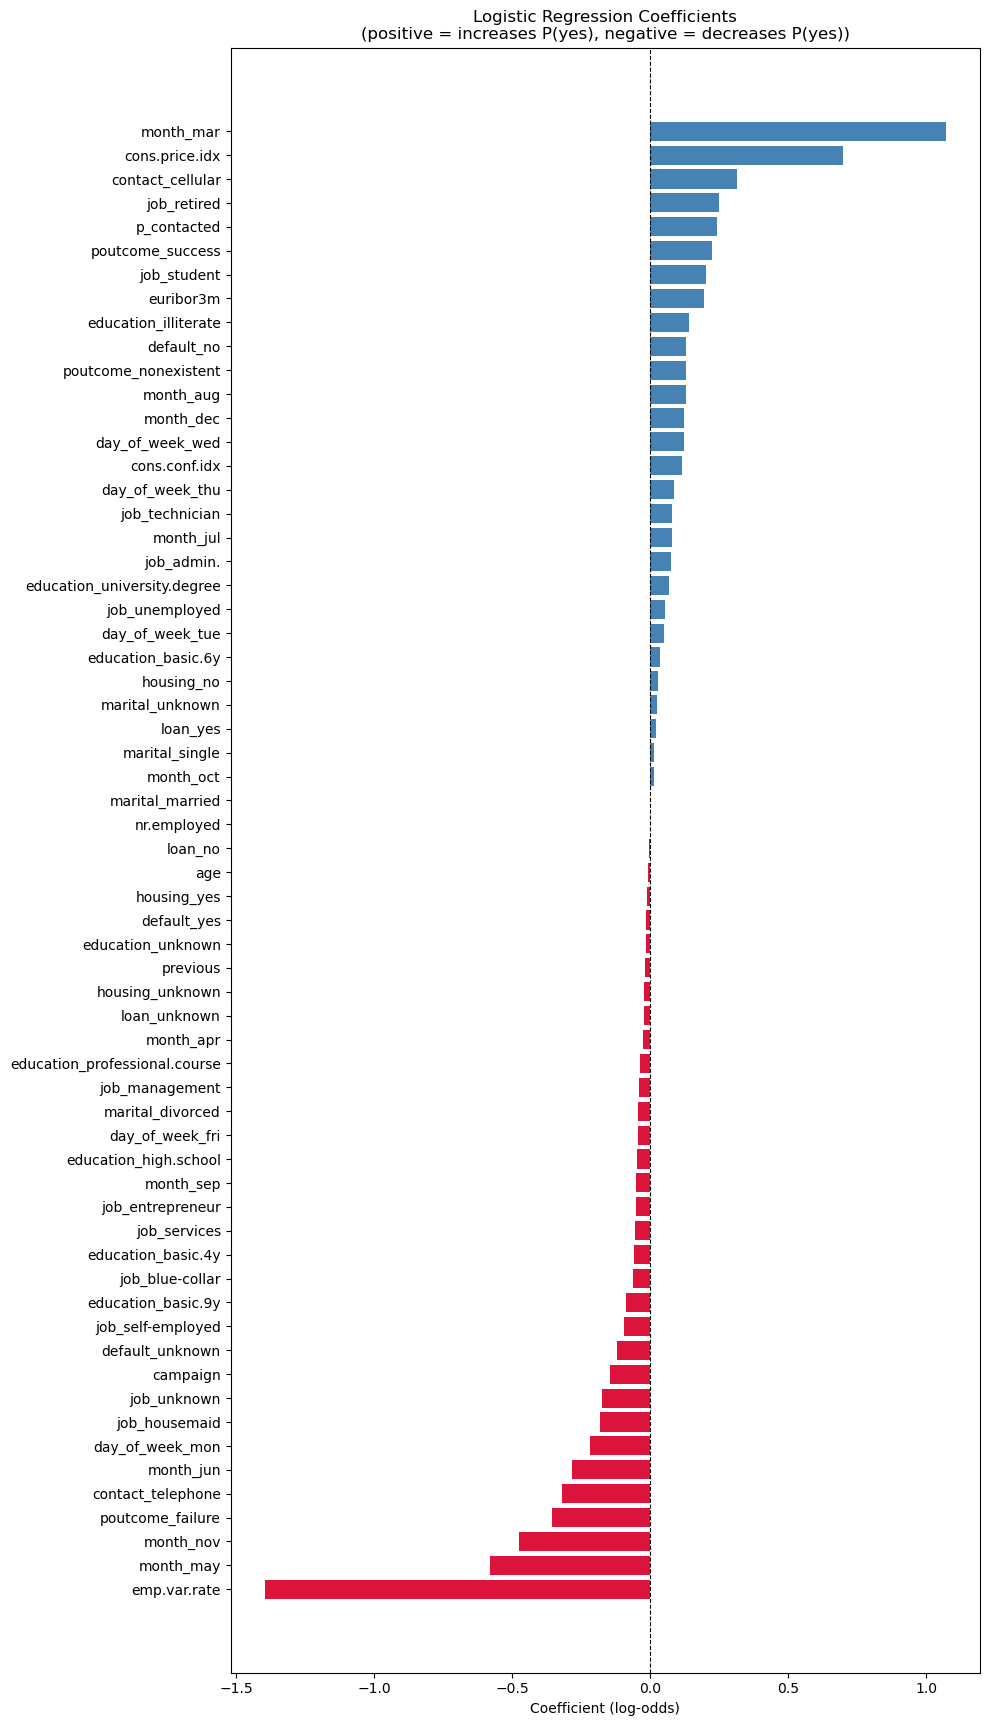

In [44]:
# Use the best LR estimator from GridSearchCV
best_lr = gs_results[0]['best_estimator']

# Recover feature names from the fitted preprocessor
ohe_features = (best_lr.named_steps['preprocessor']
                        .named_transformers_['onehotencoder']
                        .get_feature_names_out(cat_cols))
feature_names = num_cols + list(ohe_features)

# Extract coefficients (shape: 1 x n_features for binary classification)
coefs = best_lr.named_steps['model'].coef_[0]

coef_df = (pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
             .sort_values('Coefficient', ascending=False))

# Split positive / negative for colour coding
colors = ['steelblue' if c > 0 else 'crimson' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(10, max(6, len(coef_df) * 0.28)))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Logistic Regression Coefficients\n(positive = increases P(yes), negative = decreases P(yes))')
ax.invert_yaxis()
plt.tight_layout()
plt.show()